# Decision Tree from Scratch


In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [25]:
from sklearn.datasets import load_wine
from sklearn import tree
data = load_wine()
#convert to a dataframe
df = pd.DataFrame(data.data, columns = data.feature_names)
#create the species column
df['Class'] = data.target
#replace this with the actual names
target = np.unique(data.target)
target_names = np.unique(data.target_names)
targets = dict(zip(target, target_names))
df['Class'] = df['Class'].replace(targets)

In [26]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [27]:
#extract features and target variables
x = df.drop(columns="Class")
y = df["Class"]
#save the feature name and target variables
feature_names = x.columns
labels = y.unique()
#split the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,
                                                 test_size = 0.3,
                                                 random_state = 42)

In [28]:
from collections import Counter

class Node:
    def __init__(self, left=None, right=None, feature=None, threshold=None, value=None):
        self.left = left
        self.right = right
        self.feature = feature
        self.threshold = threshold
        self.value = value

class DecisionTreeClassifier:
    def __init__(self, max_depth, min_samples_leaf):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf

    def fit(self, X, y):
        self.root = self.branch(X, y)

    def branch(self, X, y, depth=0):
        num_samples = X.shape[0]
        # Return leaf node if we've reached the max depth, min samples, or only have one predicted value left
        if depth >= self.max_depth or num_samples < self.min_samples_leaf or len(y.unique()) == 1:
            return Node(value=Counter(y).most_common(1)[0][0])

        feature, threshold = self.select_threshold(X, y)
        
        left_idxs, right_idxs = self.split(X[feature], threshold)

        left_X, left_y = X.loc[left_idxs], y.loc[left_idxs]
        right_X, right_y = X.loc[right_idxs], y.loc[right_idxs]

        return Node(left=self.branch(left_X, left_y, depth=depth+1), right=self.branch(right_X, right_y, depth=depth+1), feature=feature, threshold=threshold)

    def select_threshold(self, X, y):
        max_info_gain = -1
        y_entropy = self.entropy(y)
        for feature in X:
            feature_col = X[feature]
            thresholds = feature_col.unique()
            for threshold in thresholds:
                info_gain = self.information_gain(feature_col, threshold, y, y_entropy)

                if info_gain > max_info_gain:
                    max_info_gain = info_gain
                    selected_feature = feature
                    selected_threshold = threshold
        return selected_feature, selected_threshold

    def information_gain(self, feature_col, threshold, y, y_entropy):
        left_idxs, right_idxs = self.split(feature_col, threshold)

        left_entropy = self.entropy(y.loc[left_idxs])
        right_entropy = self.entropy(y.loc[right_idxs])

        return y_entropy - (len(left_idxs)/len(y) * left_entropy) - (len(right_idxs)/len(y) * right_entropy)

    def split(self, feature_col, threshold):
        left_idxs = feature_col[feature_col <= threshold].index
        right_idxs = feature_col[feature_col > threshold].index
        return left_idxs, right_idxs

    def entropy(self, y):
        probs = y.value_counts() / len(y)
        return -np.sum([p * np.log2(p) for p in probs])
    
    def predict(self, X):
        return X.apply(lambda x: self.pred(x, self.root), axis=1)

    def pred(self, x, node):
        if node.value:
            return node.value
        if(x[node.feature] <= node.threshold):
            return self.pred(x, node.left)
        else:
            return self.pred(x, node.right)
        
    def print_tree(self):
        return self.print_tr(self.root)

    def print_tr(self, node, depth=0):
        if node.value:
            print(('\t' * depth) + "class: " + str(node.value))
            return
        print(('\t' * depth) + node.feature + " <= " + str(node.threshold))
        self.print_tr(node.left, depth=depth + 1)
        print(('\t' * depth) + node.feature + " > " + str(node.threshold))
        self.print_tr(node.right, depth=depth + 1)

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix

clf_model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5)
clf_model.fit(X_train,y_train)

y_predict = clf_model.predict(X_test)
y_predict_train = clf_model.predict(X_train)

clf_model.print_tree()

print(accuracy_score(y_test,y_predict))
print(accuracy_score(y_train,y_predict_train))

od280/od315_of_diluted_wines <= 2.15
	hue <= 0.89
		flavanoids <= 1.39
			class: class_2
		flavanoids > 1.39
			class: class_1
	hue > 0.89
		alcohol <= 12.69
			class: class_1
		alcohol > 12.69
			class: class_2
od280/od315_of_diluted_wines > 2.15
	alcohol <= 12.72
		class: class_1
	alcohol > 12.72
		color_intensity <= 3.8
			class: class_1
		color_intensity > 3.8
			class: class_0
0.8333333333333334
0.9838709677419355


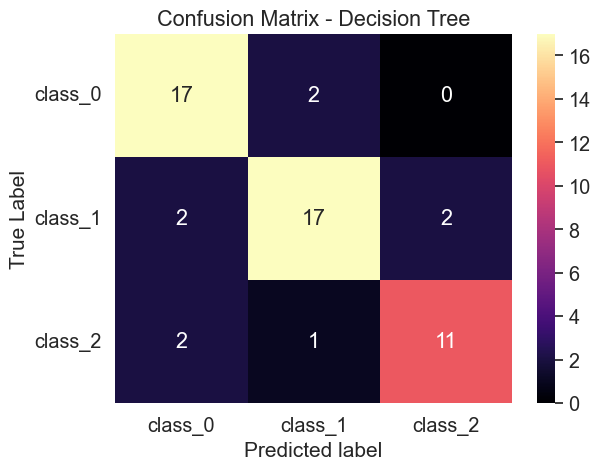

<Figure size 1000x700 with 0 Axes>

In [30]:
#import the relevant packages
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
#get the confusion matrix
confusion_matrix = metrics.confusion_matrix(y_test,
                                            y_predict)
#turn this into a dataframe
matrix_df = pd.DataFrame(confusion_matrix)
#plot the result
ax = plt.axes()
sns.set(font_scale=1.3)
plt.figure(figsize=(10,7))
sns.heatmap(matrix_df, annot=True, fmt="g", ax=ax, cmap="magma")
#set axis titles
ax.set_title('Confusion Matrix - Decision Tree')
ax.set_xlabel("Predicted label", fontsize =15)
ax.set_xticklabels(['']+labels)
ax.set_ylabel("True Label", fontsize=15)
ax.set_yticklabels(list(labels), rotation = 0)
plt.show()

In [31]:
from sklearn.metrics import accuracy_score

clf_model = DecisionTreeClassifier(max_depth=1, min_samples_leaf=5)
clf_model.fit(X_train,y_train)

y_predict = clf_model.predict(X_test)
y_predict_train = clf_model.predict(X_train)

clf_model.print_tree()

print(accuracy_score(y_test,y_predict))
print(accuracy_score(y_train,y_predict_train))

od280/od315_of_diluted_wines <= 2.15
	class: class_2
od280/od315_of_diluted_wines > 2.15
	class: class_1
0.5555555555555556
0.6290322580645161


In [32]:
from sklearn.metrics import accuracy_score

clf_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5)
clf_model.fit(X_train,y_train)

y_predict = clf_model.predict(X_test)
y_predict_train = clf_model.predict(X_train)

clf_model.print_tree()

print(accuracy_score(y_test,y_predict))
print(accuracy_score(y_train,y_predict_train))

od280/od315_of_diluted_wines <= 2.15
	hue <= 0.89
		flavanoids <= 1.39
			class: class_2
		flavanoids > 1.39
			class: class_1
	hue > 0.89
		alcohol <= 12.69
			class: class_1
		alcohol > 12.69
			class: class_2
od280/od315_of_diluted_wines > 2.15
	alcohol <= 12.72
		class: class_1
	alcohol > 12.72
		color_intensity <= 3.8
			malic_acid <= 1.67
				class: class_1
			malic_acid > 1.67
				class: class_0
		color_intensity > 3.8
			class: class_0
0.8518518518518519
0.9919354838709677
